<a href="https://colab.research.google.com/github/Thashmikab/offshore-wind-layout-cable-tradeoff/blob/main/07_life_cycle_impacts_siting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 07 · Life cycle impacts of siting and layout (Brightway + NSGA-II)

The same 8 × 10 MW farm and design variables as notebook 06, with LCOE swapped for life cycle GWP per MWh.
Brightway 2.5 runs inside the notebook: ecoinvent 3.9.1 (APOS) and ReCiPe 2016 v1.03 midpoint (H)
give an impact per kg for 13 material classes, in four categories: climate change (GWP100),
material resources (SOP), water use and terrestrial ecotoxicity (TETP).

- **Turbines:** component masses from power laws fitted to Li et al. (2022), Fig. S3, with material
  shares from their Table 1 (geared PMSG nacelle, glass-fibre rotor, steel tower, jacket).
- **Cables:** copper, lead, XLPE, steel armour and other polymers per km, estimated from the geometry in
  ABB's *XLPE Submarine Cable Systems* (rev. 5) and checked against the listed cable weights.
- **Objective:** GWP per MWh = (turbines + array cable + export cable) / (AEP × 25 years).

**Licence.** The Brightway cells need an ecoinvent licence: add `ECOINVENT_USER` and `ECOINVENT_PASS` as
Colab secrets. The database import takes 10–15 minutes. Without a licence, set `USE_BRIGHTWAY = False`
and the notebook loads the published factors from `data/lca_factors_materials.csv`. Only aggregated
impact results are shown; no ecoinvent inventory data is included.

In [ ]:
%pip install -q py_wake==2.6.20 topfarm==2.6.2 pymoo==0.6.2
%pip install -q brightway25

In [ ]:
#@title Settings
USE_BRIGHTWAY = True     # False = no ecoinvent licence: load precomputed factors from data/
FACTORS_CSV = "data/lca_factors_materials.csv"

from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.csgraph import minimum_spanning_tree
from py_wake.site import XRSite
from py_wake.site.xrsite import GlobalWindAtlasSite
from py_wake.examples.data.dtu10mw import DTU10MW
from py_wake.literature.gaussian_models import Niayifar_PorteAgel_2016
from py_wake.turbulence_models import CrespoHernandez
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

FIG = Path("figures"); FIG.mkdir(exist_ok=True)
Path("data").mkdir(exist_ok=True)

if USE_BRIGHTWAY:
    import bw2io as bi
    import bw2data as bd
    import bw2calc as bc
    try:                                   # Colab: credentials from the Secrets panel
        from google.colab import userdata
        EI_USER, EI_PASS = userdata.get("ECOINVENT_USER"), userdata.get("ECOINVENT_PASS")
    except ImportError:                    # locally: environment variables
        import os
        EI_USER, EI_PASS = os.environ["ECOINVENT_USER"], os.environ["ECOINVENT_PASS"]

## Turbine mass model and material composition

In [8]:
#@title Turbine mass model (Li et al., 2022)
# Size relations: Li et al. (2022) SI, Fig. S2 (published equations)
# Component masses: power laws fitted to Li et al. (2022) SI, Fig. S3 (digitised by the author, ~±10%)

def rotor_diameter(C_mw):
    return 62.69 * C_mw ** 0.46

def hub_height(D_m):
    return 4.93 * (D_m ** 2) ** 0.31

def component_masses_t(C_mw, foundation="jacket"):
    D = rotor_diameter(C_mw)
    H = hub_height(D)
    masses = {
        "nacelle": 285 * (D / 148) ** 2.14,           # geared PMSG
        "rotor":   165 * (D / 148) ** 2.56,           # glass-fibre blades + hub
        "tower":   390 * (D**2 * H / 2.3e6) ** 0.69,  # steel tower
    }
    if foundation == "jacket":
        masses["foundation"] = 1150 * (C_mw / 6.5) ** 1.255
    else:
        masses["foundation"] = 1700 * (C_mw / 6.5) ** 1.235   # monopile
    return D, H, masses




# Share of component mass by material class (Li et al. 2022, Table 1)
COMPOSITION = {
    "nacelle":    {"cast_iron": 0.415, "steel_high_alloy": 0.393, "steel_low_alloy": 0.103,
                   "copper": 0.022, "aluminium": 0.009, "electronics": 0.004},   # PMSG-GB
    "rotor":      {"cast_iron": 0.258, "steel_high_alloy": 0.094, "steel_low_alloy": 0.098,
                   "copper": 0.001, "aluminium": 0.001, "glass_fibre": 0.373, "resin": 0.175},
    "tower":      {"steel_low_alloy": 0.971, "copper": 0.009, "aluminium": 0.010, "electronics": 0.010},
    "foundation": {"steel_low_alloy": 0.858, "concrete": 0.142},                  # jacket
}

## Material impact factors from Brightway

In [43]:
#@title Brightway project and ecoinvent import
if USE_BRIGHTWAY:
    bd.projects.set_current("Offshore")
    if "ecoinvent-3.9.1-apos" not in bd.databases:
        bi.import_ecoinvent_release(version="3.9.1", system_model="apos",
                                    username=EI_USER, password=EI_PASS)

In [48]:
#@title Find ecoinvent activities (checks every name)
if USE_BRIGHTWAY:


    ei = bd.Database("ecoinvent-3.9.1-apos")
    LOCATION_PREFERENCE = ["GLO", "RER", "Europe without Switzerland", "RoW"]

    def find(name):
        hits = [a for a in ei if a["name"] == name]
        if not hits:
            raise ValueError(f"Not found in ecoinvent: '{name}' - search with ei.search() and fix the name")
        hits.sort(key=lambda a: LOCATION_PREFERENCE.index(a["location"])
                  if a["location"] in LOCATION_PREFERENCE else 99)
        return hits[0]

    CONCRETE_DENSITY = 2400   # kg/m3 (assumption)

    # material class -> list of (activity name, amount per kg of material)
    MAPPING = {
        "steel_low_alloy":  [("market for steel, low-alloyed", 1),
                             ("market for hot rolling, steel", 1)],
        "steel_high_alloy": [("market for steel, chromium steel 18/8", 1),
                             ("market for metal working, average for chromium steel product manufacturing", 1)],
        "cast_iron":        [("market for cast iron", 1),
                             ("market for metal working, average for steel product manufacturing", 1)],
        "copper":           [("market for copper, cathode", 1),
                             ("market for wire drawing, copper", 1)],
        "aluminium":        [("market for aluminium, wrought alloy", 1),
                             ("market for sheet rolling, aluminium", 1)],
        "glass_fibre":      [("market for glass fibre", 1)],
        "resin":            [("market for epoxy resin, liquid", 1)],
        "electronics":      [("market for electronics, for control units", 1)],
        "concrete":         [("market for concrete, normal strength", 1 / CONCRETE_DENSITY)],
        "lead":          [("market for lead", 1)],
        "steel_armour":  [("market for steel, low-alloyed", 1), ("market for wire drawing, steel", 1)],
        "xlpe":          [("market for polyethylene, low density, granulate", 1),
                          ("market for extrusion, plastic pipes", 1)],
        "polymer_other": [("market for polypropylene, granulate", 1)],
    }

    # Resolve every name first, so all problems show up at once
    resolved = {}
    for material, steps in MAPPING.items():
        resolved[material] = [(find(name), amount) for name, amount in steps]
        for act, amount in resolved[material]:
            print(f"{material:18s} | {act['name']} | {act['location']} | {act['unit']}")

steel_low_alloy    | market for steel, low-alloyed | GLO | kilogram
steel_low_alloy    | market for hot rolling, steel | GLO | kilogram
steel_high_alloy   | market for steel, chromium steel 18/8 | GLO | kilogram
steel_high_alloy   | market for metal working, average for chromium steel product manufacturing | GLO | kilogram
cast_iron          | market for cast iron | GLO | kilogram
cast_iron          | market for metal working, average for steel product manufacturing | GLO | kilogram
copper             | market for copper, cathode | GLO | kilogram
copper             | market for wire drawing, copper | GLO | kilogram
aluminium          | market for aluminium, wrought alloy | GLO | kilogram
aluminium          | market for sheet rolling, aluminium | GLO | kilogram
glass_fibre        | market for glass fibre | GLO | kilogram
resin              | market for epoxy resin, liquid | RER | kilogram
electronics        | market for electronics, for control units | GLO | kilogram
concrete           

In [49]:
#@title List the ReCiPe midpoint (H) categories
if USE_BRIGHTWAY:
    MIDPOINT = "ReCiPe 2016 v1.03, midpoint (H)"      # exact match: excludes the "no LT" variants
    recipe = [m for m in bd.methods if m[1] == MIDPOINT]


In [50]:
#@title Impact per kg of each material class
if USE_BRIGHTWAY:
    # short name -> start of the ReCiPe category name (check against the list above)
    CATEGORIES = {
        "GWP100": "climate change",
        "SOP":    "material resources: metals/minerals",
        "water":  "water use",
        "TETP":   "ecotoxicity: terrestrial",
    }

    METHODS, UNITS = {}, {}
    for short, category in CATEGORIES.items():
        hits = [m for m in recipe if m[2].startswith(category)]
        assert len(hits) == 1, f"{short}: expected one method, found {hits}"
        METHODS[short] = hits[0]
        UNITS[short] = bd.Method(hits[0]).metadata.get("unit")
        print(short, "->", hits[0][2], "|", hits[0][3], "|", UNITS[short])

    def impact(activity, amount, method):
        fu, data_objs, _ = bd.prepare_lca_inputs({activity: amount}, method=method)
        lca = bc.LCA(fu, data_objs=data_objs)
        lca.lci(); lca.lcia()
        return lca.score

    rows = {}
    for material, steps in resolved.items():
        rows[material] = {short: sum(impact(act, amount, method) for act, amount in steps)
                          for short, method in METHODS.items()}

    IMPACT_PER_KG = pd.DataFrame(rows).T          # rows: materials, columns: categories
    IMPACT_PER_KG.columns = [f"{c} ({UNITS[c]}/kg)" for c in IMPACT_PER_KG.columns]
    print(IMPACT_PER_KG.round(4).to_string())

GWP100 -> climate change | global warming potential (GWP100) | kg CO2-Eq
SOP -> material resources: metals/minerals | surplus ore potential (SOP) | kg Cu-Eq
water -> water use | water consumption potential (WCP) | m3
TETP -> ecotoxicity: terrestrial | terrestrial ecotoxicity potential (TETP) | kg 1,4-DCB-Eq
                  GWP100 (kg CO2-Eq/kg)  SOP (kg Cu-Eq/kg)  water (m3/kg)  TETP (kg 1,4-DCB-Eq/kg)
steel_low_alloy                  2.5666             0.3488         0.0236                  14.2226
steel_high_alloy                 7.9848             0.6452         0.0503                 205.9388
cast_iron                        4.1878             0.4122         0.0231                  21.1420
copper                           8.2903             1.8376         0.1508                3379.6761
aluminium                       15.0434             0.2288         0.0886                  16.9804
glass_fibre                      2.6044             0.0546         0.0162                  28.884

In [ ]:
#@title Save the factors (with Brightway) or load them (without)
if USE_BRIGHTWAY:
    IMPACT_PER_KG.to_csv(FACTORS_CSV)
else:
    IMPACT_PER_KG = pd.read_csv(FACTORS_CSV, index_col=0)

METHODS = [col.split(" (")[0] for col in IMPACT_PER_KG.columns]            # GWP100, SOP, water, TETP
UNITS = {col.split(" (")[0]: col.split(" (")[1].replace("/kg)", "") for col in IMPACT_PER_KG.columns}

## Turbine impacts

In [89]:
#@title Impacts of one turbine (materials + processing)
PER_KG = {c: IMPACT_PER_KG.iloc[:, i].to_dict() for i, c in enumerate(METHODS)}

def turbine_impacts(C_mw, foundation="jacket"):
    D, H, masses = component_masses_t(C_mw, foundation)
    totals = {c: 0.0 for c in METHODS}
    for component, mass_t in masses.items():
        for material, share in COMPOSITION[component].items():
            for c in METHODS:
                totals[c] += mass_t * 1000 * share * PER_KG[c][material]
    return totals

for C in [8, 10, 12]:
    t = turbine_impacts(C)
    print(f"{C} MW | " + " | ".join(f"{c}: {v / C:,.0f} {UNITS[c]}/MW" for c, v in t.items()))

8 MW | GWP100: 946,457 kg CO2-Eq/MW | SOP: 107,120 kg Cu-Eq/MW | water: 7,891 m3/MW | TETP: 13,801,099 kg 1,4-DCB-Eq/MW
10 MW | GWP100: 967,380 kg CO2-Eq/MW | SOP: 109,757 kg Cu-Eq/MW | water: 8,078 m3/MW | TETP: 13,846,354 kg 1,4-DCB-Eq/MW
12 MW | GWP100: 985,840 kg CO2-Eq/MW | SOP: 112,085 kg Cu-Eq/MW | water: 8,243 m3/MW | TETP: 13,893,624 kg 1,4-DCB-Eq/MW


                  mass_share  GWP100   SOP  water  TETP
cast_iron                7.8    10.9   9.5    7.2   3.9
steel_high_alloy         6.1    16.3  11.6   12.3  29.4
steel_low_alloy         71.8    61.7  73.9   67.9  23.9
copper                   0.5     1.3   2.5    2.8  36.8
aluminium                0.3     1.6   0.2    1.1   0.1
electronics              0.2     2.6   1.1    2.6   3.0
glass_fibre              3.2     2.8   0.5    2.1   2.1
resin                    1.5     2.5   0.6    3.8   0.7
concrete                 8.7     0.4   0.1    0.1   0.1


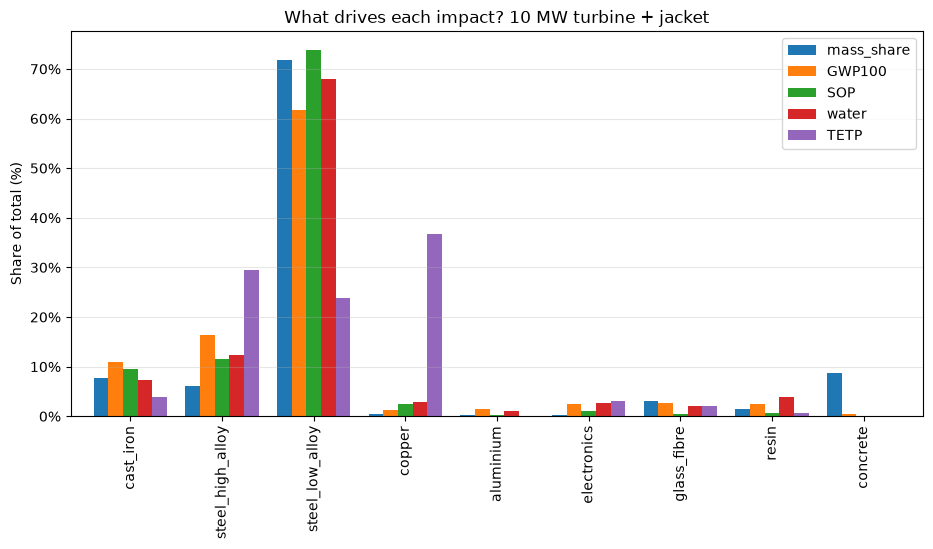

In [52]:
#@title Contribution by material (10 MW turbine)
def contributions(C_mw, foundation="jacket"):
    D, H, masses = component_masses_t(C_mw, foundation)
    material_kg = {}
    for component, mass_t in masses.items():
        for material, share in COMPOSITION[component].items():
            material_kg[material] = material_kg.get(material, 0) + mass_t * 1000 * share
    rows = {m: {c: kg * PER_KG[c][m] for c in METHODS} for m, kg in material_kg.items()}
    df = pd.DataFrame(rows).T
    df.insert(0, "mass_share", pd.Series(material_kg) / sum(material_kg.values()))
    return df / df.sum()                      # everything as a share of the total

share = contributions(10)
print((share * 100).round(1).to_string())

share.plot.bar(figsize=(11, 5), width=0.8)
plt.ylabel("Share of total (%)")
plt.title("What drives each impact? 10 MW turbine + jacket")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
plt.grid(axis="y", alpha=0.3)
plt.savefig(FIG / "07_contribution_by_material.png", dpi=150, bbox_inches="tight")
plt.show()

## Cable inventory and impacts

In [44]:
#@title Cable material inventory from ABB (2010) geometry, per metre
RHO = {"copper": 8960, "lead": 11340, "steel": 7850, "xlpe": 950}   # kg/m3

# ABB "XLPE Submarine Cable Systems" rev 5, three-core cables with lead sheath (Tables 45, 47, 49)
# name: (conductor mm2, conductor dia mm, dia over insulation mm, lead thickness mm, outer dia mm, weight Cu kg/m, armour wire mm)
CABLES = {
    "array_66kV_3x400":   (400, 23.2, 43.6, 1.7, 141, 39.2, 5),
    "export_132kV_3x300": (300, 20.4, 54.8, 2.1, 167, 48.0, 5),
    "export_220kV_3x1000":(1000, 37.9, 87.3, 3.1, 241, 104.0, 6),
}

def cable_materials_kg_per_m(A, d_cond, d_ins, t_lead, OD, weight, wire, serving=4.0, lay=1.03):
    m = {}
    m["copper"] = 3 * A * 1e-6 * RHO["copper"]
    m["xlpe"]   = 3 * np.pi / 4 * (d_ins**2 - d_cond**2) * 1e-6 * RHO["xlpe"]
    m["lead"]   = 3 * np.pi * (d_ins + t_lead) * t_lead * 1e-6 * RHO["lead"]
    D_mean = OD - 2 * serving - wire                                  # armour layer mid-diameter
    m["steel_armour"] = np.pi * D_mean * np.pi * wire / 4 * 1e-6 * RHO["steel"] * lay
    m["polymer_other"] = weight - sum(m.values())                     # fillers, sheaths, serving
    return m

CABLE_KG_PER_M = pd.DataFrame({k: cable_materials_kg_per_m(*v) for k, v in CABLES.items()}).T
print((CABLE_KG_PER_M).round(2).to_string())       # kg/m = t/km

                     copper   xlpe   lead  steel_armour  polymer_other
array_66kV_3x400      10.75   3.05   8.23         12.77           4.40
export_132kV_3x300     8.06   5.79  12.77         15.36           6.01
export_220kV_3x1000   26.88  13.84  29.95         27.17           6.15


In [53]:
#@title Cable impacts per km
CABLE_IMPACT_PER_KM = {
    cable: {c: sum(CABLE_KG_PER_M.loc[cable, m] * 1000 * PER_KG[c][m]      # kg/m -> kg/km
                   for m in CABLE_KG_PER_M.columns)
            for c in METHODS}
    for cable in CABLE_KG_PER_M.index
}
print(pd.DataFrame(CABLE_IMPACT_PER_KM).T.div(1000).round(1).to_string())   # tonnes-eq per km

                     GWP100   SOP  water     TETP
array_66kV_3x400      157.8  26.0    2.4  36998.1
export_132kV_3x300    162.9  23.0    2.3  28215.3
export_220kV_3x1000   406.8  65.4    6.2  92934.5


## Wind farm and whole-farm impacts

In [93]:
#@title Wind farm variables
N_TURBINES = 8
TURBINE_DIAMETER = 178.3            # DTU 10 MW rotor diameter (m)
MIN_SPACING = 4 * TURBINE_DIAMETER
wt = DTU10MW()
TI = 0.06
LIFETIME_YR = 25                    # same as notebook 06
C_MW = 10.0

LEASE_X, LEASE_Y = 3000, 2000
D_REF_KM = 146.65                   # GWA Dogger Bank point, measured from the coast at Flamborough Head
D_MIN_KM, D_MAX_KM = 10, 150
POP_SIZE, N_GEN, SEED = 80, 100, 1

In [60]:
#@title Whole-farm impacts

ARRAY_CABLE = "array_66kV_3x400"
# Standalone 80 MW farm:
EXPORT_CABLE, EXPORT_SHARE = "export_132kV_3x300", 1.0
# Unit cell of a larger farm (use instead, and change the export cost to match):
# EXPORT_CABLE, EXPORT_SHARE = "export_220kV_3x1000", N_TURBINES * C_MW / 300

TURBINE = turbine_impacts(C_MW)             # per turbine, computed once

def farm_impacts(array_km, export_km):
    return {c: N_TURBINES * TURBINE[c]
               + array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE][c]
               + export_km * EXPORT_SHARE * CABLE_IMPACT_PER_KM[EXPORT_CABLE][c]
            for c in METHODS}

def contribution_split(array_km, export_km):
    parts = {
        "turbines": {c: N_TURBINES * TURBINE[c] for c in METHODS},
        "array":    {c: array_km * CABLE_IMPACT_PER_KM[ARRAY_CABLE][c] for c in METHODS},
        "export":   {c: export_km * EXPORT_SHARE * CABLE_IMPACT_PER_KM[EXPORT_CABLE][c] for c in METHODS},
    }
    df = pd.DataFrame(parts)
    return df.div(df.sum(axis=1), axis=0)          # shares per category

print((contribution_split(array_km=4.7, export_km=50) * 100).round(1).to_string())

        turbines  array  export
GWP100      89.7    0.9     9.4
SOP         87.3    1.2    11.4
water       83.6    1.5    14.9
TETP        41.1    6.5    52.4


## Wind resource

In [55]:
DATA = Path("data/dogger_bank_gwa.nc")

def load_dogger_bank_site():
    """Dogger Bank wind climate from the Global Wind Atlas (54.75 N, 1.90 E, 119 m, open sea).
    Downloaded once and cached in data/ so later runs don't depend on the GWA API."""
    if DATA.exists():
        return XRSite(xr.load_dataset(DATA))
    print("Downloading Dogger Bank wind climate from the Global Wind Atlas...")
    site = GlobalWindAtlasSite(lat=54.75, long=1.90, height=119, roughness=0.0002)
    DATA.parent.mkdir(exist_ok=True)
    site.ds.to_netcdf(DATA)
    return site


base_gwa_site = load_dogger_bank_site()

In [57]:
# 1. Load the CSV file once
transect_df = pd.read_csv("https://raw.githubusercontent.com/Thashmikab/offshore-wind-layout-cable-tradeoff/refs/heads/main/data/dogger_bank_transect.csv")

# Extract arrays for blazing-fast numpy operations
KNOWN_DISTANCES = transect_df['distance_km'].values
KNOWN_SCALES    = transect_df['U_rel'].values

def calculate_transect_scale_factor(distance_to_shore_km):
    """
    Empirically scales wind speed based on a Global Wind Atlas transect
    running from the Yorkshire coast out to Dogger Bank.
    """
    # Clip the incoming distance to ensure safe lookup bounds [0, 160]
    query_dist = np.clip(distance_to_shore_km, KNOWN_DISTANCES[0], KNOWN_DISTANCES[-1])

    # Linearly interpolate the scaling factor
    scale_factor = np.interp(query_dist, KNOWN_DISTANCES, KNOWN_SCALES)
    return float(scale_factor)


#print(calculate_transect_scale_factor(10))


In [58]:
#@title Instantiate the wake physics engine

wind_farm_model = Niayifar_PorteAgel_2016(
    site=base_gwa_site,
    windTurbines=wt,
    turbulenceModel=CrespoHernandez() # Matches the Niayifar 2016 publication standard
)

## Optimisation: energy vs GWP per MWh

In [122]:
#@title Objective function



def evaluate_wind_farm_layout(variables):
    """
    variables = [x1..x8, y1..y8, distance to shore km]
    Objectives: maximise AEP, minimise life cycle GWP per MWh.
    """

    # 1. Unpack variables
    x_coords = np.array(variables[0:N_TURBINES])
    y_coords = np.array(variables[N_TURBINES:2 * N_TURBINES])
    dist_shore_km = variables[-1]

    coords = np.column_stack((x_coords, y_coords))
    # Compute the pairwise Euclidean distances
    # This returns a compressed, flat array of all distinct pairs
    distances = pdist(coords)




    # OBJECTIVE 1: Minimize (-AEP)
    # Scale the Weibull A parameter (which sets the mean wind speed) by the transect factor

    scale_factor = calculate_transect_scale_factor(dist_shore_km)
    scaled_ds = base_gwa_site.ds.copy(deep=True)
    scaled_ds["Weibull_A"] = base_gwa_site.ds["Weibull_A"] * scale_factor
    scaled_ds["TI"] = TI
    wind_farm_model.site = XRSite(scaled_ds)


    x_offshore = x_coords + dist_shore_km * 1000
    aep_gwh = wind_farm_model(x_offshore, y_coords).aep().sum().values
    obj_energy = -aep_gwh






    # OBJECTIVE 2: Minimise GWP per MWh


    # Compute Minimum Spanning Tree of the turbine nodes
    dist_matrix = squareform(distances)
    mst_graph = minimum_spanning_tree(dist_matrix)         # calculates the path that connects all 8 turbines together such that the total length of the path is as short as possible, without creating any closed loops.
    array_cable_km = mst_graph.toarray().sum() / 1000.0    # Convert meters to km


    export_cable_km = dist_shore_km

    impacts = farm_impacts(array_cable_km, export_cable_km)
    lifetime_mwh = aep_gwh * 1000 * LIFETIME_YR
    gwp_per_mwh = impacts["GWP100"] / lifetime_mwh        # kg CO2e/MWh = g CO2e/kWh





    # Constraint: closest pair must be at least MIN_SPACING apart (<= 0 means OK)
    spacing_violation = MIN_SPACING - distances.min()





    return [obj_energy, gwp_per_mwh], spacing_violation

In [132]:
#@title Test the objective function on the starting grid

x0 = np.linspace(0, 2400, 4).repeat(2)
y0 = np.tile(np.linspace(0, 800, 2), 4)

test_layout = np.concatenate([x0, y0, [100]])    # 4x2 grid, 100 km offshore
objectives, violation = evaluate_wind_farm_layout(test_layout)

print(f"AEP:          {-objectives[0]:.1f} GWh")
print(f"Total GWP:    {objectives[1]:.2f} kg CO2 per MWh")
print(f"Spacing OK:   {violation <= 0}")


AEP:          377.5 GWh
Total GWP:    10.02 kg CO2 per MWh
Spacing OK:   True


In [63]:
#@title NSGA-II problem

class WindFarmProblem(ElementwiseProblem):

    def __init__(self):
        lower = [0] * N_TURBINES + [0] * N_TURBINES + [D_MIN_KM]              # x, y, distance
        upper = [LEASE_X] * N_TURBINES + [LEASE_Y] * N_TURBINES + [D_MAX_KM]
        super().__init__(n_var=2 * N_TURBINES + 1,   # 17 variables
                         n_obj=2,              # energy, GWP per MWh
                         n_ieq_constr=1,       # spacing
                         xl=lower, xu=upper)

    def _evaluate(self, v, out, *args, **kwargs):
        objectives, spacing_violation = evaluate_wind_farm_layout(v)
        out["F"] = objectives
        out["G"] = [spacing_violation]

In [66]:
#@title Run NSGA-II

problem = WindFarmProblem()

# Starting population: random layouts, plus the 4x2 grid so at least one is feasible
rng = np.random.default_rng(SEED)
X0 = rng.uniform(problem.xl, problem.xu, size=(POP_SIZE, problem.n_var))
X0[0] = np.concatenate([x0, y0, [D_REF_KM]])

result = minimize(problem,
                  NSGA2(pop_size=POP_SIZE, sampling=X0),
                  ("n_gen", N_GEN),
                  seed=SEED,
                  verbose=False)


In [134]:
#@title Get the full pareto front

front = pd.DataFrame({
    "Distance_to_shore_km": result.X[:, -1],
    "AEP_GWh":              -result.F[:, 0],
    "GWP_kg_per_MWh": result.F[:, 1],
}).sort_values("Distance_to_shore_km").reset_index(drop=True)

print(f"{len(front)} trade-off layouts found")
print(front.round(1).to_string())

In [135]:
#@title Pareto front: AEP vs GWP per MWh
plt.figure(figsize=(9, 5))
sc = plt.scatter(front.AEP_GWh, front.GWP_kg_per_MWh, c=front.Distance_to_shore_km, cmap="viridis", s=40)
plt.colorbar(sc, label="Distance to shore (km)")
plt.xlabel("AEP (GWh)"); plt.ylabel("Life cycle GWP (kg CO2e/MWh)")
plt.title("Energy vs life cycle GWP, 8 × DTU 10 MW off the Yorkshire coast")
plt.grid(True, alpha=0.3)
plt.savefig(FIG / "07_pareto_gwp_aep.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
#@title All impact categories along the front
rows = []
for v in result.X:
    x, y, d = v[:N_TURBINES], v[N_TURBINES:2 * N_TURBINES], v[-1]
    (neg_aep, _), _ = evaluate_wind_farm_layout(v)
    lifetime_mwh = -neg_aep * 1000 * LIFETIME_YR
    array_km = minimum_spanning_tree(squareform(pdist(np.column_stack([x, y])))).sum() / 1000
    impacts = farm_impacts(array_km, d)
    rows.append({"Distance_km": d, **{f"{c}_per_MWh": impacts[c] / lifetime_mwh for c in METHODS}})
impacts_front = pd.DataFrame(rows).sort_values("Distance_km").reset_index(drop=True)
cols = [f"{c}_per_MWh" for c in METHODS]
rel = impacts_front[cols] / impacts_front[cols].iloc[0]
print(rel.iloc[[0, -1]].round(2).to_string())

plt.figure(figsize=(9, 5))
for c in cols:
    plt.plot(impacts_front.Distance_km, rel[c], marker="o", ms=3, label=c.replace("_per_MWh", ""))
plt.axhline(1, color="grey", lw=0.8)
plt.xlabel("Distance to shore (km)"); plt.ylabel("Impact per MWh (relative to nearest design)")
plt.title("How each impact category responds to moving offshore (8 × 10 MW)")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(FIG / "07_categories_vs_distance.png", dpi=150, bbox_inches="tight")
plt.show()